In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools as it
import matplotlib.patches as mpatches

In [2]:
test = pd.read_excel('../01data_noupload/CBDI3_NSS.xlsx')

In [3]:
stan_scores_list = test.columns[test.columns.str.contains(' SS', case = True)]
stan_scores_list

Index(['Adaptive-Self Care SS', 'Adaptive-Personal Responsibility SS',
       'Social Emotional-Adult Interaction SS',
       'Social Emotional-Peer Interaction SS',
       'Social Emotional-Self Concept / Social Role SS',
       'Communication-Receptive Communication SS',
       'Communication-Expressive Communication SS', 'Motor-Gross Motor SS',
       'Motor-Fine Motor SS', 'Motor-Perceptual Motor SS',
       'Cognitive-Attention and Memory SS',
       'Cognitive-Reasoning / Academic Skills SS',
       'Cognitive-Perception and Concepts SS'],
      dtype='object')

In [4]:
stand_scores = test[stan_scores_list]

In [5]:
stats_test = test[stan_scores_list].describe()

In [6]:
max_mean = stats_test.iloc[1:2].max(axis = 1)
max_mean_c = stats_test.iloc[1:2].idxmax(axis=1)

min_mean = stats_test.iloc[1:2].min(axis = 1)
min_mean_c = stats_test.iloc[1:2].idxmin(axis=1)

print(f'Highest Scoring Subdomain is {max_mean_c.iloc[0]} with a {max_mean.iloc[0].round(2)} mean')
print(f'Lowest Scoring Subdomain is {min_mean_c.iloc[0]} with a {min_mean.iloc[0].round(2)} mean')


Highest Scoring Subdomain is Social Emotional-Adult Interaction SS with a 10.45 mean
Lowest Scoring Subdomain is Communication-Expressive Communication SS with a 6.49 mean


In [7]:
df_fg = pd.melt(stand_scores)

In [8]:
stand_scores.shape

(19500, 13)

In [9]:
df_fg['domain'] = 'Unassigned'
df_fg.loc[df_fg['variable'].str.contains('Adaptive'),'domain'] = 'Adaptive'
df_fg.loc[df_fg['variable'].str.contains('Social'),'domain'] = 'Social-Emotional'
df_fg.loc[df_fg['variable'].str.contains('Motor'),'domain'] = 'Motor'
df_fg.loc[df_fg['variable'].str.contains('Communication'),'domain'] = 'Communication'
df_fg.loc[df_fg['variable'].str.contains('Cognitive'),'domain'] = 'Cognitive'

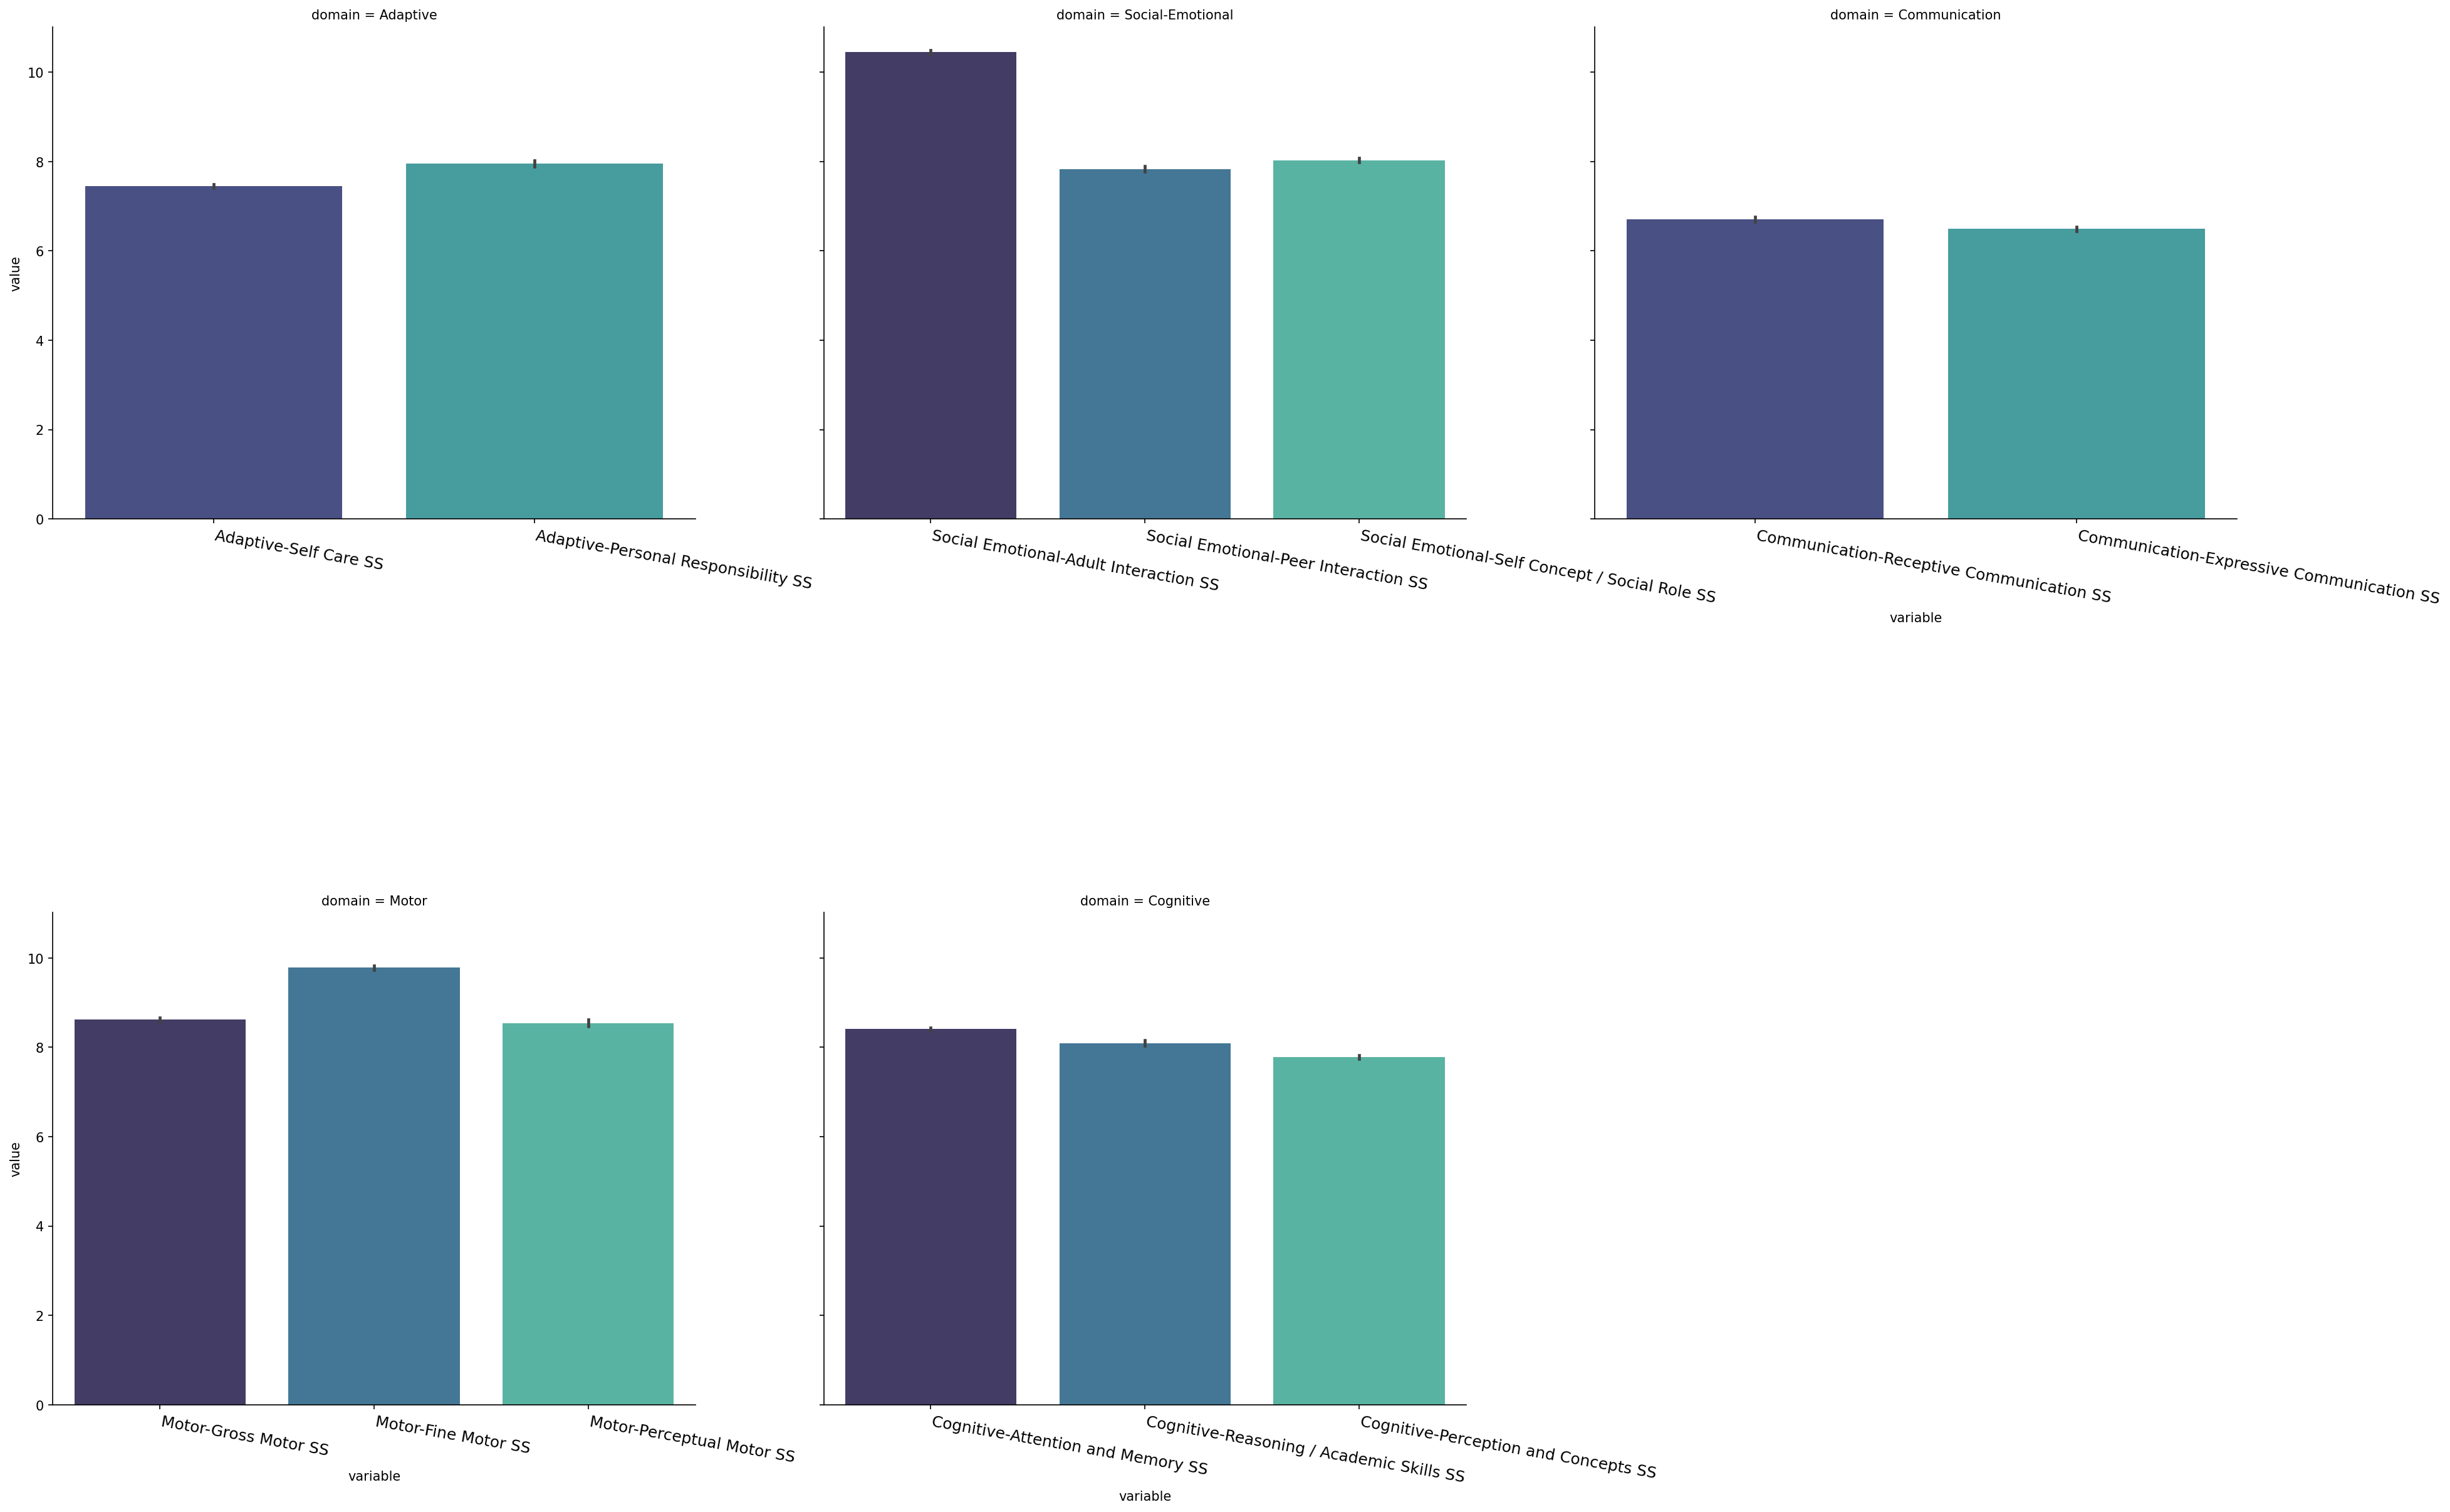

In [43]:
plt.rcParams['figure.dpi'] = 150
g = sns.FacetGrid(
    df_fg,
    col = "domain",
    col_wrap = 3,
    sharex = False,
    sharey = True,
    aspect = .8,
    height = 10,
)

g.map_dataframe(
    sns.barplot,
    x="variable",
    y="value",
    hue = "variable",
    palette = "mako",
    legend = False
)
g.fig.patch.set_facecolor('none')
for ax in g.axes.flat:
    ax.set_facecolor('none')
    ax.tick_params(axis='x', labelrotation=-10,labelsize = 12)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('left')    
plt.subplots_adjust(hspace = .8, wspace = .2, bottom = .25)
plt.show()

In [11]:
main_domains_list = test.columns[test.columns.str.contains('Sum of Scaled Scores', case = True)]
main_domains = test[main_domains_list]

In [12]:
main_domains

,Adaptive Sum of Scaled Scores,Social-Emotional Sum of Scaled Scores,Communication Sum of Scaled Scores,Motor Sum of Scaled Scores,Cognitive Sum of Scaled Scores,BDI-3 Total Sum of Scaled Scores
0,7.0,29.0,17.0,16.0,20.0,89.0
1,16.0,32.0,19.0,31.0,30.0,128.0
2,8.0,17.0,14.0,23.0,15.0,77.0
3,13.0,21.0,16.0,17.0,24.0,91.0
4,5.0,11.0,10.0,11.0,19.0,56.0
...,...,...,...,...,...,...
19495,13.0,25.0,24.0,26.0,24.0,112.0
19496,25.0,38.0,24.0,38.0,41.0,166.0
19497,21.0,31.0,5.0,32.0,29.0,118.0
19498,16.0,25.0,12.0,30.0,24.0,107.0


In [13]:
main_domains.mean().sort_values(ascending = False)

BDI-3 Total Sum of Scaled Scores         89.863036
Motor Sum of Scaled Scores               22.655334
Social-Emotional Sum of Scaled Scores    22.381153
Cognitive Sum of Scaled Scores           20.220933
Communication Sum of Scaled Scores       13.201500
Adaptive Sum of Scaled Scores            11.412712
dtype: float64

In [14]:
domains_ss = pd.melt(main_domains)

In [15]:
domains_ss.rename(columns = {'variable':'domain', 'value':'ss_score'})

,domain,ss_score
0,Adaptive Sum of Scaled Scores,7.0
1,Adaptive Sum of Scaled Scores,16.0
2,Adaptive Sum of Scaled Scores,8.0
3,Adaptive Sum of Scaled Scores,13.0
4,Adaptive Sum of Scaled Scores,5.0
...,...,...
116995,BDI-3 Total Sum of Scaled Scores,112.0
116996,BDI-3 Total Sum of Scaled Scores,166.0
116997,BDI-3 Total Sum of Scaled Scores,118.0
116998,BDI-3 Total Sum of Scaled Scores,107.0


In [16]:
test.columns[test.columns.str.contains('Sum of Scaled Scores', case = True)]

Index(['Adaptive Sum of Scaled Scores',
       'Social-Emotional Sum of Scaled Scores',
       'Communication Sum of Scaled Scores', 'Motor Sum of Scaled Scores',
       'Cognitive Sum of Scaled Scores', 'BDI-3 Total Sum of Scaled Scores'],
      dtype='object')

In [17]:
test.columns[test.columns.str.contains('Developmental Quotient', case = True)]


Index(['Adaptive Developmental Quotient',
       'Social-Emotional Developmental Quotient',
       'Communication Developmental Quotient', 'Motor Developmental Quotient',
       'Cognitive Developmental Quotient',
       'BDI-3 Total Developmental Quotient'],
      dtype='object')

In [18]:
z_columns = test.columns[test.columns.str.contains('Z-Score', case = True)].sort_values(ascending = False)
z_score = test[z_columns]
z_score

,Social-Emotional Z-Score,Social Emotional-Self Concept / Social Role Z-Score,Social Emotional-Peer Interaction Z-Score,Social Emotional-Adult Interaction Z-Score,Motor-Perceptual Motor Z-Score,Motor-Gross Motor Z-Score,Motor-Fine Motor Z-Score,Motor Z-Score,Communication-Receptive Communication Z-Score,Communication-Expressive Communication Z-Score,Communication Z-Score,Cognitive-Reasoning / Academic Skills Z-Score,Cognitive-Perception and Concepts Z-Score,Cognitive-Attention and Memory Z-Score,Cognitive Z-Score,BDI-3 Total Z-Score,Adaptive-Self Care Z-Score,Adaptive-Personal Responsibility Z-Score,Adaptive Z-Score
0,1.8,1.67,NaN,1.33,NaN,– 1.00,– 0.33,– 0.80,– 0.67,– 0.33,– 0.60,NaN,1,– 1.00,0,– 0.07,– 1.00,NaN,– 1.00
1,0.27,0.33,– 0.33,0.67,0.33,– 1.00,1,0.13,0,– 0.33,– 0.20,1.33,– 1.00,– 0.33,0,– 0.07,– 1.00,– 0.33,– 0.80
2,– 0.60,– 1.33,NaN,0.33,NaN,0.33,0.67,0.6,– 1.00,– 1.00,– 1.20,NaN,– 1.00,– 0.67,– 1.13,– 0.73,– 0.67,NaN,– 0.67
3,0.2,0.33,NaN,0,NaN,– 1.67,0.67,– 0.60,– 0.67,– 0.67,– 0.80,NaN,0,1.33,0.87,0.07,1,NaN,1
4,– 1.80,– 1.67,NaN,– 1.33,NaN,– 2.33,– 0.67,– 1.80,– 1.67,– 1.67,– 2.00,NaN,0,– 0.33,– 0.20,– 1.93,– 1.67,NaN,– 1.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19495,1,0.67,NaN,1,NaN,0.33,1.67,1.2,0.67,0.67,0.8,NaN,1.67,– 0.33,0.87,1.27,1,NaN,1
19496,1.07,1,1,0.67,0.67,1.67,0.33,1.13,1.33,0,0.8,1.33,1.33,1,1.47,1.27,0,1.67,1
19497,0.13,– 0.33,0,0.67,0.33,0.33,0,0.27,– 2.00,– 3.00,– 3.00,– 0.33,0,0,– 0.13,– 0.40,0,0.33,0.2
19498,– 0.67,– 1.33,0.33,– 0.67,0.33,– 0.33,0,0,– 1.00,– 1.67,– 1.60,– 0.67,– 0.33,– 1.00,– 0.80,– 0.80,– 1.33,0,– 0.80


In [19]:
z_score_subs = z_score.drop(columns = ['Social-Emotional Z-Score','Motor Z-Score','Communication Z-Score','Adaptive Z-Score','Cognitive Z-Score','BDI-3 Total Z-Score'])
z_score_subs.rename(columns = {'Adaptive–Self Care Z-Score': 'Adaptive-Self Care Z-Score', 'Adaptive-Personal Responsibility Z-Score':'Adaptive-Personal Responsibility Z-Score'})
z_score_subs

,Social Emotional-Self Concept / Social Role Z-Score,Social Emotional-Peer Interaction Z-Score,Social Emotional-Adult Interaction Z-Score,Motor-Perceptual Motor Z-Score,Motor-Gross Motor Z-Score,Motor-Fine Motor Z-Score,Communication-Receptive Communication Z-Score,Communication-Expressive Communication Z-Score,Cognitive-Reasoning / Academic Skills Z-Score,Cognitive-Perception and Concepts Z-Score,Cognitive-Attention and Memory Z-Score,Adaptive-Self Care Z-Score,Adaptive-Personal Responsibility Z-Score
0,1.67,NaN,1.33,NaN,– 1.00,– 0.33,– 0.67,– 0.33,NaN,1,– 1.00,– 1.00,NaN
1,0.33,– 0.33,0.67,0.33,– 1.00,1,0,– 0.33,1.33,– 1.00,– 0.33,– 1.00,– 0.33
2,– 1.33,NaN,0.33,NaN,0.33,0.67,– 1.00,– 1.00,NaN,– 1.00,– 0.67,– 0.67,NaN
3,0.33,NaN,0,NaN,– 1.67,0.67,– 0.67,– 0.67,NaN,0,1.33,1,NaN
4,– 1.67,NaN,– 1.33,NaN,– 2.33,– 0.67,– 1.67,– 1.67,NaN,0,– 0.33,– 1.67,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19495,0.67,NaN,1,NaN,0.33,1.67,0.67,0.67,NaN,1.67,– 0.33,1,NaN
19496,1,1,0.67,0.67,1.67,0.33,1.33,0,1.33,1.33,1,0,1.67
19497,– 0.33,0,0.67,0.33,0.33,0,– 2.00,– 3.00,– 0.33,0,0,0,0.33
19498,– 1.33,0.33,– 0.67,0.33,– 0.33,0,– 1.00,– 1.67,– 0.67,– 0.33,– 1.00,– 1.33,0


In [20]:
z_columns_dict = {}
for col in z_score_subs.columns:
    domain_name = col.replace('Z-Score', '').split('-')[0].strip()
    if domain_name not in z_columns_dict:
        z_columns_dict[domain_name] = []
    z_columns_dict[domain_name].append(col)

In [21]:
type(z_score_subs['Adaptive-Personal Responsibility Z-Score'])

pandas.core.series.Series

In [22]:
z_columns_dict

{'Social Emotional': ['Social Emotional-Self Concept / Social Role Z-Score',
  'Social Emotional-Peer Interaction Z-Score',
  'Social Emotional-Adult Interaction Z-Score'],
 'Motor': ['Motor-Perceptual Motor Z-Score',
  'Motor-Gross Motor Z-Score',
  'Motor-Fine Motor Z-Score'],
 'Communication': ['Communication-Receptive Communication Z-Score',
  'Communication-Expressive Communication Z-Score'],
 'Cognitive': ['Cognitive-Reasoning / Academic Skills Z-Score',
  'Cognitive-Perception and Concepts Z-Score',
  'Cognitive-Attention and Memory Z-Score'],
 'Adaptive': ['Adaptive-Self Care Z-Score',
  'Adaptive-Personal Responsibility Z-Score']}

In [23]:
z_score_subs = z_score_subs.apply(pd.to_numeric, errors='coerce')

In [24]:

disparity_result = []

for domain_name, col_list in z_columns_dict.items():
    for col_a, col_b in it.combinations(col_list,2):     ##Cleaning list after loop
        col_a_name = col_a.split('-')[1].replace('Z-Score','').strip()
        col_b_name = col_b.split('-')[1].replace('Z-Score','').strip()
        pair_labels= f"{col_a_name} vs {col_b_name}"

        raw_diff = z_score_subs[col_a] - z_score_subs[col_b]  ## finding z diff for disparity 
        abs_diff= raw_diff.abs()


        flagged_disparity = abs_diff >= 1.5
        flag_count = flagged_disparity.sum()
        total_kids = raw_diff.dropna().count()
        total_pct_flagged = (flag_count/total_kids) * 100 if total_kids > 0 else 0

        disparity_result.append({
            'domain':domain_name,
            'sub vs sub': pair_labels,
            'avg pair diff (Directional)': raw_diff.mean(),
            'avg ABSOLUTE diff': abs_diff.mean(),
            'max z gap': abs_diff.max(),
            'kids flagged (count)':flag_count,
            'kids flagged (%)': total_pct_flagged
        })

disparity_df = pd.DataFrame(disparity_result).sort_values(by = 'kids flagged (%)', ascending = False)

In [25]:
disparity_df

,domain,sub vs sub,avg pair diff (Directional),avg ABSOLUTE diff,max z gap,kids flagged (count),kids flagged (%)
10,Adaptive,Self Care Z vs Personal Responsibility Z,-0.371683,0.701524,3.00,100,9.960159
1,Social Emotional,Self Concept / Social Role Z vs Adult Interact...,-0.393829,0.641898,3.00,374,6.418397
3,Motor,Perceptual Motor Z vs Gross Motor Z,0.208429,0.510980,2.67,136,5.437825
4,Motor,Perceptual Motor Z vs Fine Motor Z,-0.062647,0.575478,2.34,160,4.659289
5,Motor,Gross Motor Z vs Fine Motor Z,-0.258443,0.572037,2.67,269,4.647547
8,Cognitive,Reasoning / Academic Skills Z vs Attention and...,0.250424,0.520246,3.00,54,4.017857
9,Cognitive,Perception and Concepts Z vs Attention and Mem...,0.086044,0.505233,3.00,141,3.916667
6,Communication,Receptive Communication Z vs Expressive Commun...,-0.130904,0.513131,2.33,85,3.241800
2,Social Emotional,Peer Interaction Z vs Adult Interaction Z,-0.363762,0.538923,3.00,81,2.595322
7,Cognitive,Reasoning / Academic Skills Z vs Perception an...,0.238377,0.439108,2.67,27,1.796407


Under a normal distribution (Bell Curve) probability evens out about +- 1 SD captures about 68% of populations which is the typical average, and +-1.5 only accounts for about 6.7% of populations, a gape of under 1.5 SD being less than 10% of the population makes it unlikey to be random noise

www.tn.gov/content/dam/tn/education/special-education/eligibility/se_eligibility_develop_delay.pdf -
FOR TENNESSEE it that 1.5 SD is the starting point for what is considered falling behind. Therefore, 

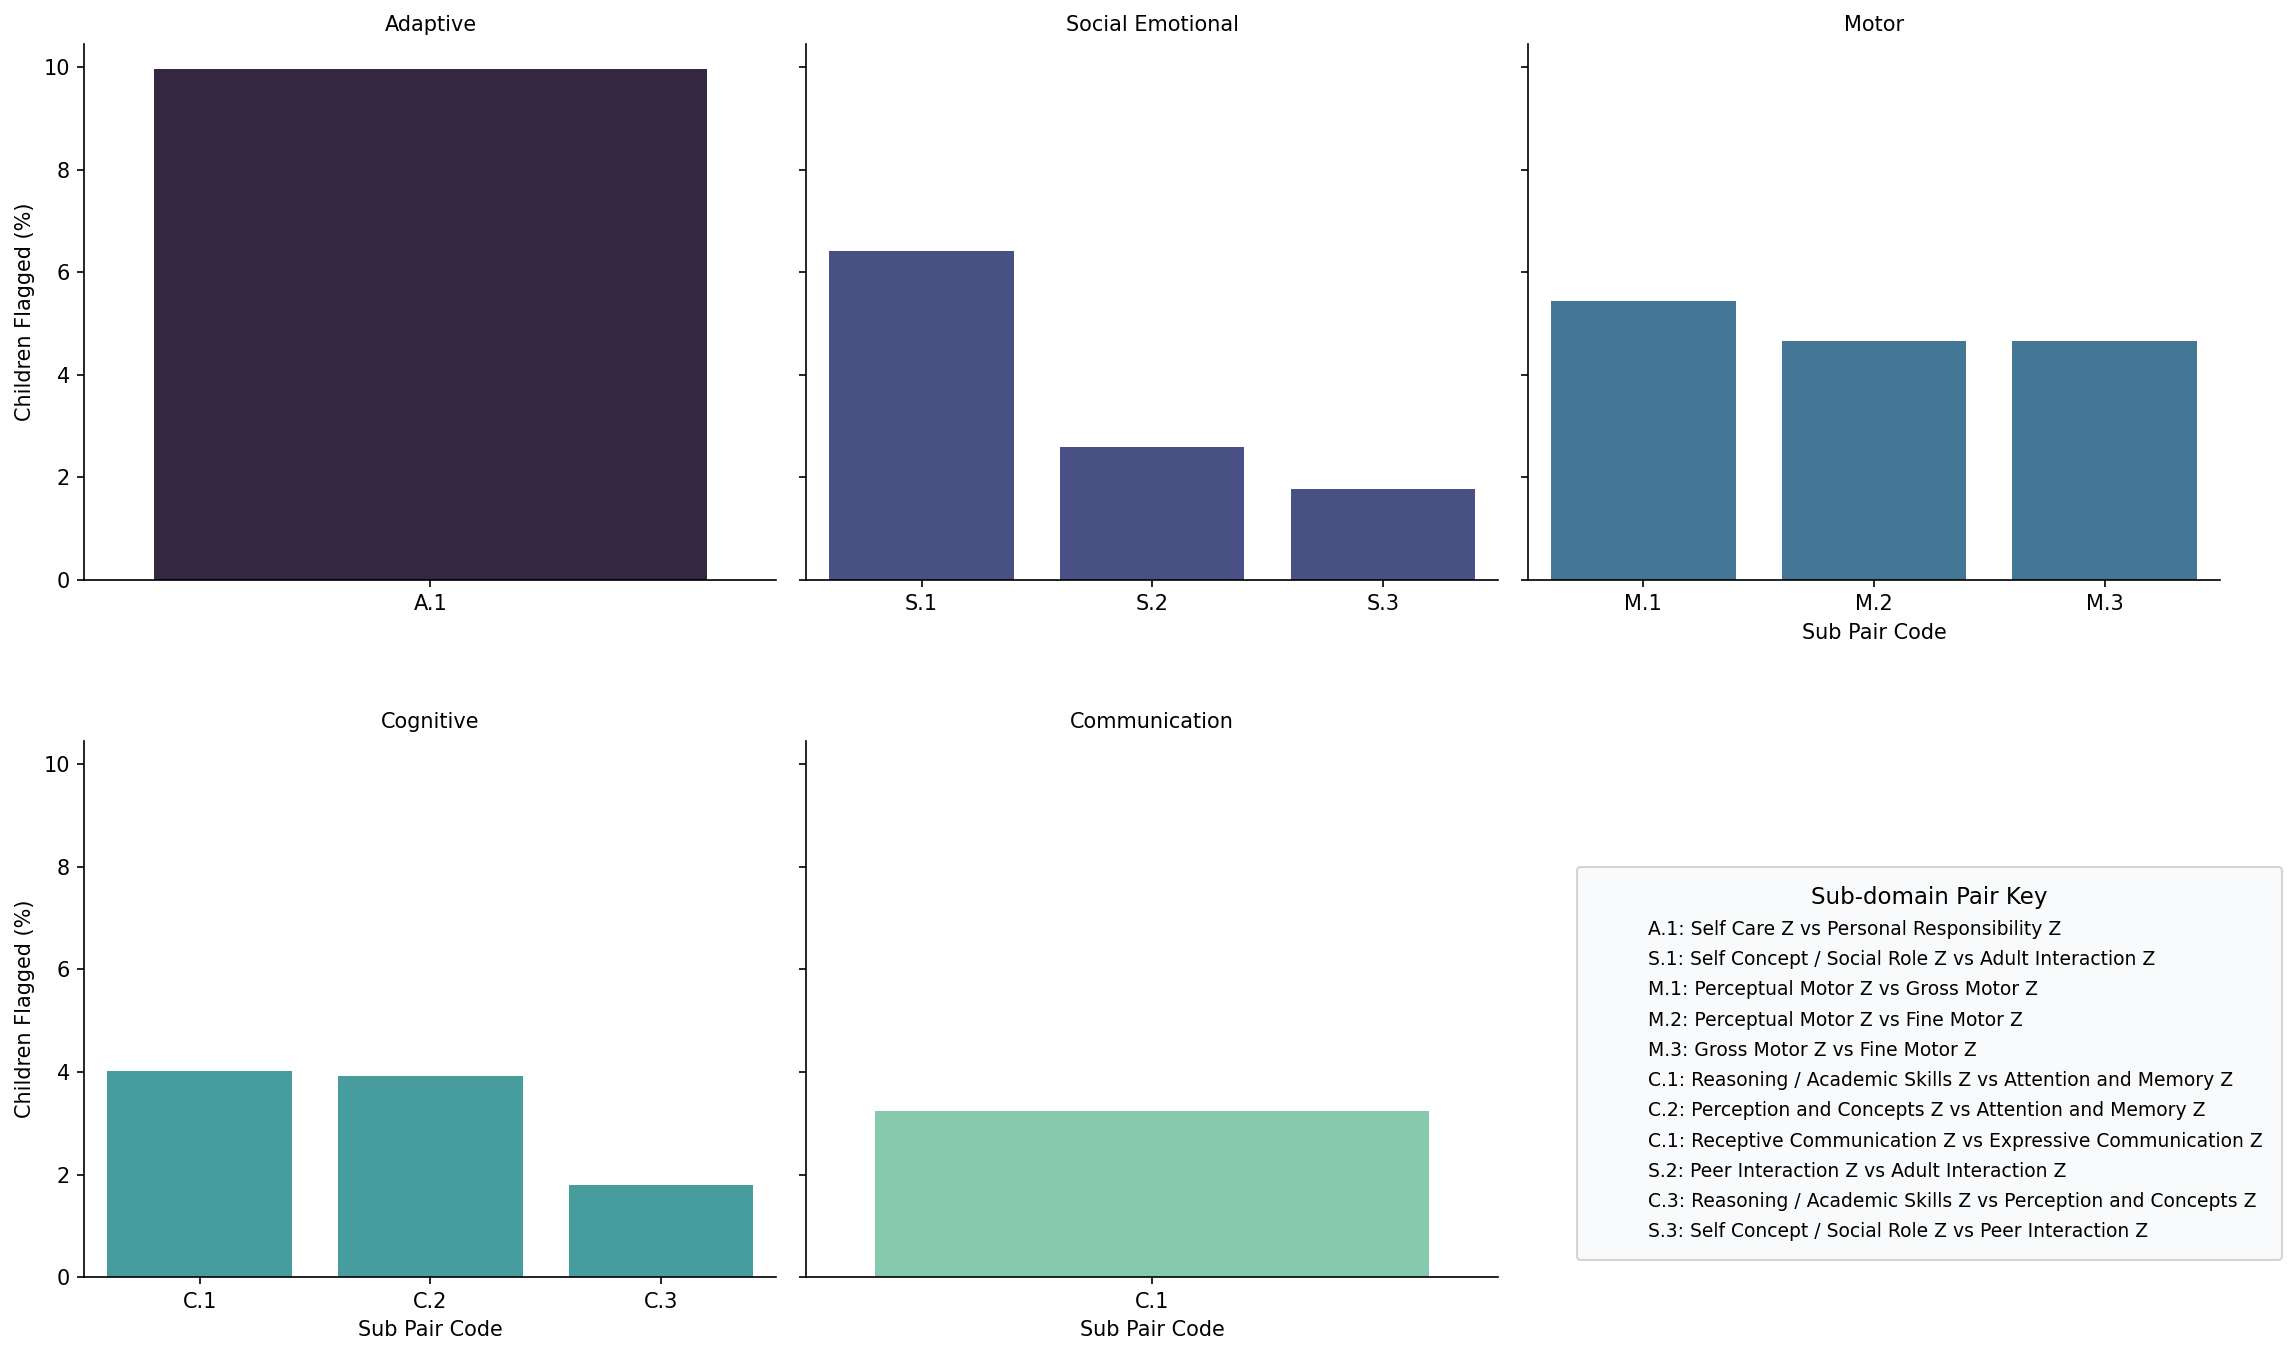

In [26]:
disparity_df = disparity_df.copy()
disparity_df['domain_code'] = disparity_df['domain'].astype('category').cat.codes + 1
disparity_df['pair_num'] = disparity_df.groupby('domain').cumcount() + 1
disparity_df['short_code'] = (
    disparity_df['domain'].str.extract(r'([A-Z])')[0] + "." + 
    disparity_df['pair_num'].astype(str)
)

g = sns.catplot(
    data = disparity_df,
    x = 'short_code',
    y = 'kids flagged (%)',
    col = 'domain',
    kind = 'bar',
    sharex = False,
    col_wrap = 3,
    palette = "mako",
    hue = 'domain',
    legend = False
)

g.fig.patch.set_facecolor('none')
for ax in g.axes.flat:
    ax.set_facecolor('none')

legend_handles = []
for _, row in disparity_df.iterrows():
    label_text = f"{row['short_code']}: {row['sub vs sub']}"

    handle = mpatches.Patch(color="none", label=label_text)
    legend_handles.append(handle)

fig_legend = g.fig.legend(
    handles = legend_handles,
    title = "Sub-domain Pair Key",
    loc = "center left",
    bbox_to_anchor = (.70, .2),  
    frameon = True,
    facecolor = "#f8f9fa",  
    edgecolor = "#cccccc",  
    fontsize =9,
    title_fontsize= 11,
    borderpad =1,
    labelspacing = 0.6,
)

g.set_axis_labels('Sub Pair Code', 'Children Flagged (%)')
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=.88, hspace=0.3)

plt.show()

In [27]:
disparity_df

,domain,sub vs sub,avg pair diff (Directional),avg ABSOLUTE diff,max z gap,kids flagged (count),kids flagged (%),domain_code,pair_num,short_code
10,Adaptive,Self Care Z vs Personal Responsibility Z,-0.371683,0.701524,3.00,100,9.960159,1,1,A.1
1,Social Emotional,Self Concept / Social Role Z vs Adult Interact...,-0.393829,0.641898,3.00,374,6.418397,5,1,S.1
3,Motor,Perceptual Motor Z vs Gross Motor Z,0.208429,0.510980,2.67,136,5.437825,4,1,M.1
4,Motor,Perceptual Motor Z vs Fine Motor Z,-0.062647,0.575478,2.34,160,4.659289,4,2,M.2
5,Motor,Gross Motor Z vs Fine Motor Z,-0.258443,0.572037,2.67,269,4.647547,4,3,M.3
8,Cognitive,Reasoning / Academic Skills Z vs Attention and...,0.250424,0.520246,3.00,54,4.017857,2,1,C.1
9,Cognitive,Perception and Concepts Z vs Attention and Mem...,0.086044,0.505233,3.00,141,3.916667,2,2,C.2
6,Communication,Receptive Communication Z vs Expressive Commun...,-0.130904,0.513131,2.33,85,3.241800,3,1,C.1
2,Social Emotional,Peer Interaction Z vs Adult Interaction Z,-0.363762,0.538923,3.00,81,2.595322,5,2,S.2
7,Cognitive,Reasoning / Academic Skills Z vs Perception an...,0.238377,0.439108,2.67,27,1.796407,2,3,C.3


In [28]:
from IPython.display import display

summary_table = disparity_df[
    ["domain",
     "sub vs sub",
     "max z gap", 
     "avg ABSOLUTE diff",  
     "kids flagged (%)",
    ]
].copy()

styled_table = (
    summary_table.style.format(
        {
            "max z gap": "{:.2f}",
            "avg ABSOLUTE diff": "{:.2f}",
            "kids flagged (%)": "{:.1f}%",
        }
    )
    .set_caption("Sub-domain Disparity & Flagged Rates Summary")
    .hide(axis="index")
    .set_properties(
        **{
            "background-color": "#ffffff",
            "color": "#111111",
            "text-align": "left",
            "padding": "6px 12px",
            "border": "1px solid #e0e0e0",
        }
    )
)

display(styled_table)

domain,sub vs sub,max z gap,avg ABSOLUTE diff,kids flagged (%)
Adaptive,Self Care Z vs Personal Responsibility Z,3.00,0.70,10.0%
Social Emotional,Self Concept / Social Role Z vs Adult Interaction Z,3.00,0.64,6.4%
Motor,Perceptual Motor Z vs Gross Motor Z,2.67,0.51,5.4%
Motor,Perceptual Motor Z vs Fine Motor Z,2.34,0.58,4.7%
Motor,Gross Motor Z vs Fine Motor Z,2.67,0.57,4.6%
Cognitive,Reasoning / Academic Skills Z vs Attention and Memory Z,3.00,0.52,4.0%
Cognitive,Perception and Concepts Z vs Attention and Memory Z,3.00,0.51,3.9%
Communication,Receptive Communication Z vs Expressive Communication Z,2.33,0.51,3.2%
Social Emotional,Peer Interaction Z vs Adult Interaction Z,3.00,0.54,2.6%
Cognitive,Reasoning / Academic Skills Z vs Perception and Concepts Z,2.67,0.44,1.8%


In [29]:
dq_list = test.columns[test.columns.str.contains('Developmental Quotient', case = True)]
dq_list

Index(['Adaptive Developmental Quotient',
       'Social-Emotional Developmental Quotient',
       'Communication Developmental Quotient', 'Motor Developmental Quotient',
       'Cognitive Developmental Quotient',
       'BDI-3 Total Developmental Quotient'],
      dtype='object')

In [30]:
dq_list_replace = dq_list.str.replace('Developmental Quotient', 'DQ')
dq_list_replace

Index(['Adaptive DQ', 'Social-Emotional DQ', 'Communication DQ', 'Motor DQ',
       'Cognitive DQ', 'BDI-3 Total DQ'],
      dtype='object')

In [31]:
dq_info = test[dq_list]

In [32]:
dq_info = dq_info.rename(columns = {'Adaptive Developmental Quotient':'Adaptive DQ',
                          'Social-Emotional Developmental Quotient':'Social-Emotional DQ',
                          'Motor Developmental Quotient':'Motor DQ',
                          'BDI-3 Total Developmental Quotient':'BDI-3 Total DQ',
                          'Cognitive Developmental Quotient':'Cognitive DQ',
                          'Communication Developmental Quotient':'Communication DQ'})

In [33]:
dq_info

,Adaptive DQ,Social-Emotional DQ,Communication DQ,Motor DQ,Cognitive DQ,BDI-3 Total DQ
0,85.0,127.0,91.0,88.0,100.0,99.0
1,88.0,104.0,97.0,102.0,100.0,99.0
2,90.0,91.0,82.0,109.0,83.0,89.0
3,115.0,103.0,88.0,91.0,113.0,101.0
4,75.0,73.0,70.0,73.0,97.0,71.0
...,...,...,...,...,...,...
19495,115.0,115.0,112.0,118.0,113.0,119.0
19496,115.0,116.0,112.0,117.0,122.0,119.0
19497,103.0,102.0,55.0,104.0,98.0,94.0
19498,88.0,90.0,76.0,100.0,88.0,88.0


In [34]:
domain_cols = [
    "Adaptive DQ",
    "Social-Emotional DQ",
    "Communication DQ",
    "Motor DQ",
    "Cognitive DQ",
]
for col in domain_cols:
    dq_info[f"{col}_25_flag"] = dq_info[col].between(71, 78)
    dq_info[f"{col}_40_flag"] = dq_info[col] <= 70

cols_25 = [f"{col}_25_flag" for col in domain_cols]
cols_40 = [f"{col}_40_flag" for col in domain_cols]

dq_info["count_25_delay"] = dq_info[cols_25].sum(axis=1)
dq_info["count_40_delay"] = dq_info[cols_40].sum(axis=1)

dq_info['Domain_eligible_current'] = (dq_info['count_40_delay'] >= 1) | (dq_info['count_25_delay'] >= 2)

dq_info['bdi_eligible'] = dq_info['BDI-3 Total DQ'] <= 70

flag_cols = [col for col in dq_info.columns if col.endswith('_flag')]
dq_info = dq_info.drop(columns=flag_cols)
    

In [35]:
dq_info

,Adaptive DQ,Social-Emotional DQ,Communication DQ,Motor DQ,Cognitive DQ,BDI-3 Total DQ,count_25_delay,count_40_delay,Domain_eligible_current,bdi_eligible
0,85.0,127.0,91.0,88.0,100.0,99.0,0,0,False,False
1,88.0,104.0,97.0,102.0,100.0,99.0,0,0,False,False
2,90.0,91.0,82.0,109.0,83.0,89.0,0,0,False,False
3,115.0,103.0,88.0,91.0,113.0,101.0,0,0,False,False
4,75.0,73.0,70.0,73.0,97.0,71.0,3,1,True,False
...,...,...,...,...,...,...,...,...,...,...
19495,115.0,115.0,112.0,118.0,113.0,119.0,0,0,False,False
19496,115.0,116.0,112.0,117.0,122.0,119.0,0,0,False,False
19497,103.0,102.0,55.0,104.0,98.0,94.0,0,1,True,False
19498,88.0,90.0,76.0,100.0,88.0,88.0,1,0,False,False


In [36]:
def compare_rules(row):
    current = row['Domain_eligible_current']
    bdi = row['bdi_eligible']

    if current and bdi:
        return 'Qualifies Under Both'
    elif current and not bdi:
        return 'Qualifies Under Domain Rule Only'
    elif bdi and not current:
        return 'Qualifies Under BDI Total Only'
    else:
        return 'Not Qualified'


dq_info['comparison_status'] = dq_info.apply(compare_rules, axis=1)

In [37]:
dq_info

,Adaptive DQ,Social-Emotional DQ,Communication DQ,Motor DQ,Cognitive DQ,BDI-3 Total DQ,count_25_delay,count_40_delay,Domain_eligible_current,bdi_eligible,comparison_status
0,85.0,127.0,91.0,88.0,100.0,99.0,0,0,False,False,Not Qualified
1,88.0,104.0,97.0,102.0,100.0,99.0,0,0,False,False,Not Qualified
2,90.0,91.0,82.0,109.0,83.0,89.0,0,0,False,False,Not Qualified
3,115.0,103.0,88.0,91.0,113.0,101.0,0,0,False,False,Not Qualified
4,75.0,73.0,70.0,73.0,97.0,71.0,3,1,True,False,Qualifies Under Domain Rule Only
...,...,...,...,...,...,...,...,...,...,...,...
19495,115.0,115.0,112.0,118.0,113.0,119.0,0,0,False,False,Not Qualified
19496,115.0,116.0,112.0,117.0,122.0,119.0,0,0,False,False,Not Qualified
19497,103.0,102.0,55.0,104.0,98.0,94.0,0,1,True,False,Qualifies Under Domain Rule Only
19498,88.0,90.0,76.0,100.0,88.0,88.0,1,0,False,False,Not Qualified


In [38]:
(dq_info['count_40_delay'] == True).sum()

np.int64(4819)

In [49]:
status_counts = dq_info["comparison_status"].value_counts()
status_counts.to_frame()

,count
comparison_status,
Not Qualified,10073
Qualifies Under Domain Rule Only,6425
Qualifies Under Both,3002


C:\Users\beris\AppData\Local\Temp\ipykernel_22944\3843519593.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(


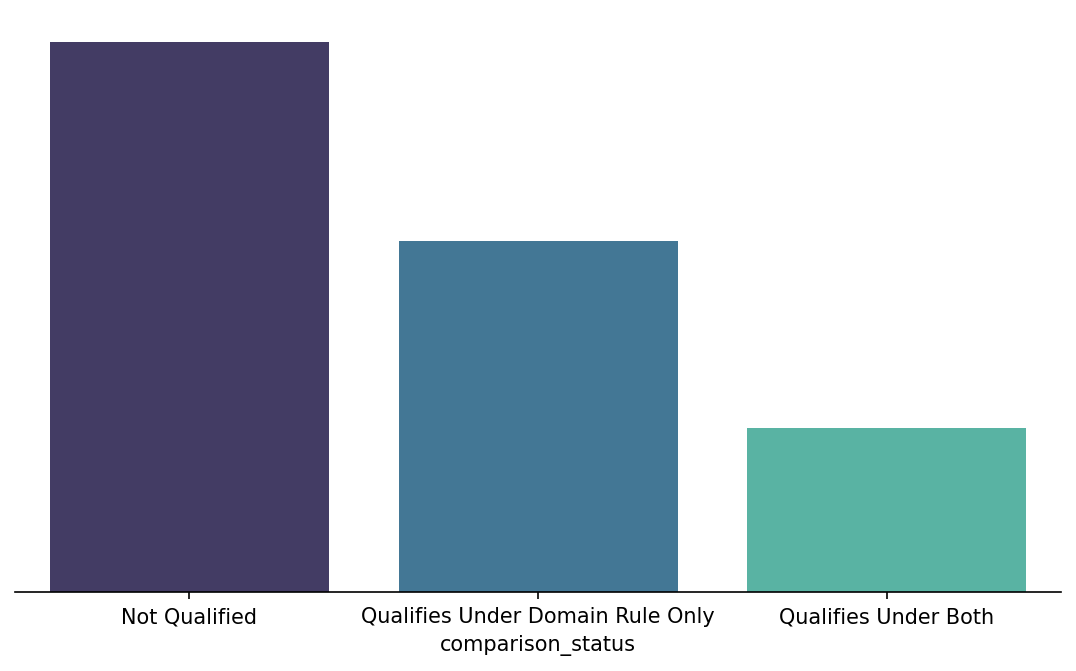

In [51]:
f, ax = plt.subplots(figsize = (9,5))
g = sns.barplot(
    data = status_counts,
    color="b",
    palette = 'mako',
)
ax.get_yaxis().set_visible(False)
sns.despine(left=True)


In [41]:
dq_info['comparison_status'].value_counts()

comparison_status
Not Qualified                       10073
Qualifies Under Domain Rule Only     6425
Qualifies Under Both                 3002
Name: count, dtype: int64

In [42]:
test['Date of Birth'].dt.year.max()

2023